First 5 rows of Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape: (20640, 9)

Feature Shape: (20640, 1)
Target Shape: (20640, 1)

Training Samples : 16512
Testing Samples  : 4128

MODEL PERFORMANCE ON TEST DATA

Normal Equation
------------------------
MSE : 1.2923314440807299
R2  : 0.013795337532284901

Gradient Descent
------------------------
MSE : 1.2923314362391949
R2  : 0.01379534351632139



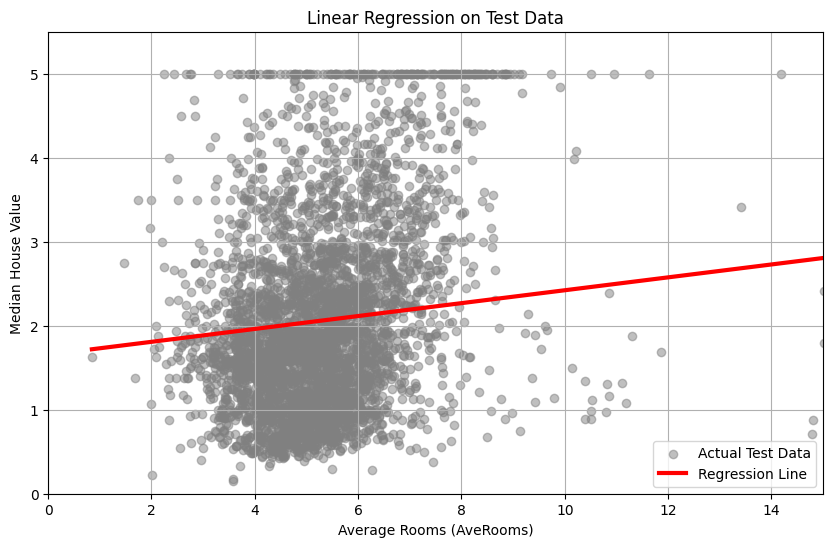

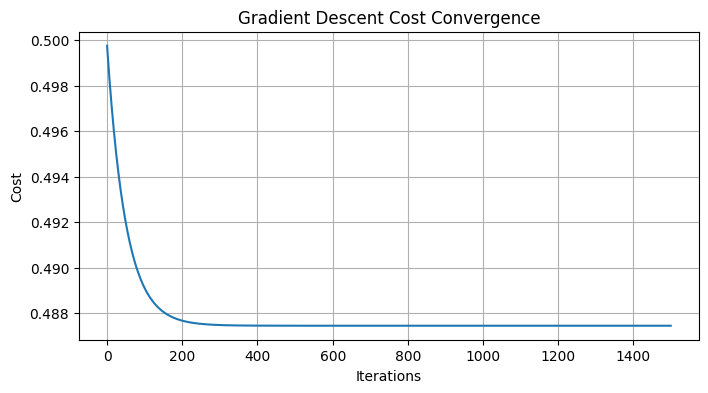


First 10 Test Predictions
    Actual  Predicted (Normal)  Predicted (Gradient)
0  0.47700            1.976537              1.976537
1  0.45800            2.041563              2.041563
2  5.00001            1.960031              1.960031
3  2.18600            2.127856              2.127856
4  2.78000            2.076380              2.076380
5  1.58700            2.057843              2.057843
6  1.98200            2.132314              2.132314
7  1.57500            2.035687              2.035687
8  3.40000            1.956002              1.956002
9  4.46600            2.182768              2.182768


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# Step 1: Load Dataset
# ==========================================

california = fetch_california_housing(as_frame=True)
df = california.frame

print("First 5 rows of Dataset:")
print(df.head())

print("\nDataset Shape:", df.shape)

# Feature and Target
X = df[['AveRooms']].values
y = df['MedHouseVal'].values.reshape(-1,1)

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)

# ==========================================
# Split into Training and Testing
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

# ==========================================
# Standardization
# ==========================================

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Add bias column

m_train = len(X_train_scaled)

X_train_b = np.c_[np.ones((m_train,1)), X_train_scaled]
X_test_b = np.c_[np.ones((len(X_test_scaled),1)), X_test_scaled]

# ==========================================
# Normal Equation
# ==========================================

theta_normal = np.linalg.inv(
    X_train_b.T.dot(X_train_b)
).dot(
    X_train_b.T
).dot(y_train_scaled)

# Prediction on Test Set

y_pred_normal_scaled = X_test_b.dot(theta_normal)
y_pred_normal = scaler_y.inverse_transform(y_pred_normal_scaled)

# ==========================================
# Gradient Descent
# ==========================================

def compute_cost(X, y, theta):

    m = len(y)

    predictions = X.dot(theta)

    cost = (1/(2*m))*np.sum((predictions-y)**2)

    return cost


def gradient_descent(X, y, theta, learning_rate, iterations):

    m = len(y)

    cost_history = []

    for i in range(iterations):

        gradients = (1/m) * X.T.dot(X.dot(theta)-y)

        theta = theta - learning_rate*gradients

        cost_history.append(compute_cost(X,y,theta))

    return theta, cost_history


learning_rate = 0.01
iterations = 1500

theta_initial = np.zeros((2,1))

theta_gd, cost_history = gradient_descent(
    X_train_b,
    y_train_scaled,
    theta_initial,
    learning_rate,
    iterations
)

# Prediction on Test Set

y_pred_gd_scaled = X_test_b.dot(theta_gd)
y_pred_gd = scaler_y.inverse_transform(y_pred_gd_scaled)

# ==========================================
# Model Evaluation
# ==========================================

mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("\n==============================")
print("MODEL PERFORMANCE ON TEST DATA")
print("==============================")

print("\nNormal Equation")
print("------------------------")
print("MSE :", mse_normal)
print("R2  :", r2_normal)

print("\nGradient Descent")
print("------------------------")
print("MSE :", mse_gd)
print("R2  :", r2_gd)

print("\nTheta (Normal Equation)")
print(theta_normal)

print("\nTheta (Gradient Descent)")
print(theta_gd)

# ==========================================
# Visualization
# ==========================================

sort_index = np.argsort(X_test.flatten())

X_sorted = X_test[sort_index]

y_pred_sorted = y_pred_gd[sort_index]

plt.figure(figsize=(10,6))

plt.scatter(
    X_test,
    y_test,
    color="gray",
    alpha=0.5,
    label="Actual Test Data"
)

plt.plot(
    X_sorted,
    y_pred_sorted,
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.title("Linear Regression on Test Data")
plt.xlabel("Average Rooms (AveRooms)")
plt.ylabel("Median House Value")

plt.xlim(0,15)
plt.ylim(0,5.5)

plt.grid(True)
plt.legend()

plt.show()

# ==========================================
# Cost Convergence
# ==========================================

plt.figure(figsize=(8,4))

plt.plot(cost_history)

plt.title("Gradient Descent Cost Convergence")

plt.xlabel("Iterations")

plt.ylabel("Cost")

plt.grid(True)

plt.show()

# ==========================================
# Display Actual vs Predicted
# ==========================================

results = pd.DataFrame({
    "Actual": y_test.flatten(),
    "Predicted (Normal)": y_pred_normal.flatten(),
    "Predicted (Gradient)": y_pred_gd.flatten()
})

print("\nFirst 10 Test Predictions")
print(results.head(10))

